# Clasificacion de contenido tecnico + extraccion de palabras clave

**Hackathon ONE - Proyectos G9 | Alura + Oracle**

## Objetivo
Recibir contenido tecnico (titulo + texto) y devolver:
- `categoria`: la clasificacion tematica del contenido (Backend, Frontend, etc.)
- `probabilidad`: la confianza del modelo en esa prediccion
- `informacion_adicional`: una lista de palabras clave relevantes del texto

## Enfoque tecnico
1. **Clasificacion**: TF-IDF + Regresion Logistica, con busqueda de hiperparametros
   (GridSearchCV) sobre validacion cruzada para maximizar la precision.
2. **Extraccion de palabras clave**: reutilizamos la misma matriz TF-IDF (no hace
   falta un modelo aparte) tomando, por documento, los terminos con mayor peso.

## Estructura del notebook
1. Carga y exploracion de datos (EDA)
2. Preprocesamiento de texto
3. Division train/test
4. Vectorizacion TF-IDF
5. Entrenamiento con busqueda de hiperparametros
6. Evaluacion (metricas + graficas)
7. Extraccion de palabras clave
8. Funcion de prediccion completa (contrato de la API)
9. Serializacion del modelo (joblib)


## 1. Imports

In [1]:
# Manipulacion de datos
import pandas as pd
import numpy as np
import re

# Serializacion del modelo entrenado
import pickle

# Machine learning: division de datos, vectorizacion, modelo, busqueda de hiperparametros
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

# Visualizacion
import matplotlib.pyplot as plt
import seaborn as sns

# Configuracion de despliegue de pandas para ver textos completos
pd.set_option('display.max_colwidth', 100)
sns.set_style('whitegrid')

## 2. Carga y exploracion de datos (EDA)

Antes de entrenar cualquier modelo, es fundamental entender los datos:
cuantos ejemplos hay, si estan balanceados entre categorias, si hay valores
faltantes o duplicados, y como se distribuye la longitud de los textos.


In [2]:
# Cargamos el dataset. Usamos 'utf-8-sig' porque el archivo fue guardado
# con BOM (Byte Order Mark) para que se vea correctamente en Excel.
df = pd.read_csv('dataset_contenidos.csv', encoding='utf-8-sig')

print(f'Filas totales: {len(df)}')
print(f'Columnas: {list(df.columns)}')
df.head()

Filas totales: 280
Columnas: ['id', 'titulo', 'texto', 'categoria', 'fuente']


,id,titulo,texto,categoria,fuente
0,1,Introducción a Spring Boot,En este contenido se presentan los conceptos básicos para la creación de APIs REST utilizando Ja...,Backend,equipo
1,2,Autenticación con JWT en Node.js,Se explica cómo implementar autenticación basada en tokens JWT en una aplicación backend constru...,Backend,equipo
2,3,Microservicios con Spring Cloud,"Este artículo describe la arquitectura de microservicios utilizando Spring Cloud, Eureka para el...",Backend,equipo
3,4,Django REST Framework para APIs,"Se muestra cómo construir una API REST en Python utilizando Django REST Framework, incluyendo se...",Backend,equipo
4,5,Manejo de excepciones en APIs REST,Este tutorial cubre las mejores prácticas para el manejo centralizado de excepciones en una API ...,Backend,equipo


In [3]:
# Distribucion de clases: queremos ver si el dataset esta balanceado.
# Un dataset muy desbalanceado hace que el modelo aprenda a favorecer
# la clase mayoritaria y falle en las minoritarias.
conteo_categorias = df['categoria'].value_counts()
print(conteo_categorias)

categoria
Backend           40
Frontend          40
Data Science      40
Mobile            40
DevOps            40
Bases de Datos    40
Cloud             40
Name: count, dtype: int64


/tmp/ipykernel_585/957542318.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=conteo_categorias.values, y=conteo_categorias.index, palette='viridis')


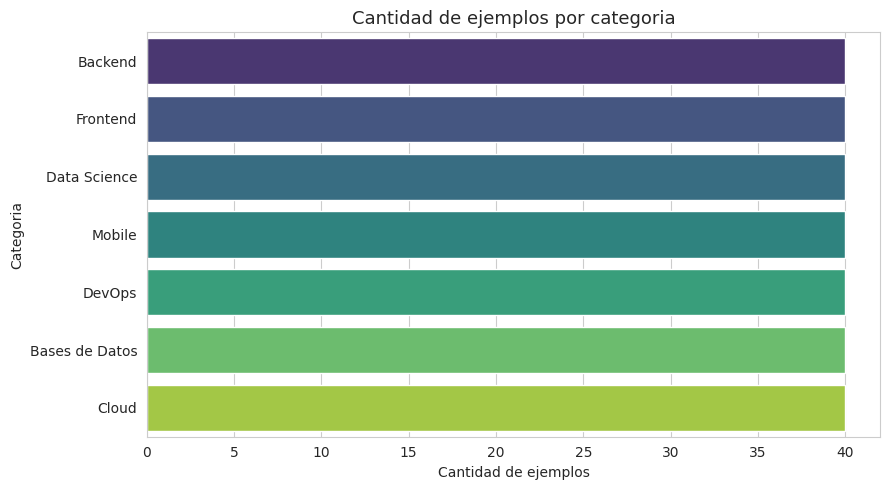

In [4]:
# Visualizamos la distribucion de categorias con un grafico de barras.
plt.figure(figsize=(9, 5))
sns.barplot(x=conteo_categorias.values, y=conteo_categorias.index, palette='viridis')
plt.title('Cantidad de ejemplos por categoria', fontsize=13)
plt.xlabel('Cantidad de ejemplos')
plt.ylabel('Categoria')
plt.tight_layout()
plt.show()

In [5]:
# Revisamos valores nulos y filas duplicadas: ambos pueden distorsionar el entrenamiento.
print('Valores nulos por columna:')
print(df.isnull().sum())
print()
print('Filas duplicadas (mismo titulo + texto):', df.duplicated(subset=['titulo', 'texto']).sum())

Valores nulos por columna:
id           0
titulo       0
texto        0
categoria    0
fuente       0
dtype: int64

Filas duplicadas (mismo titulo + texto): 0


/tmp/ipykernel_585/3880096581.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='longitud_texto', y='categoria', palette='viridis')


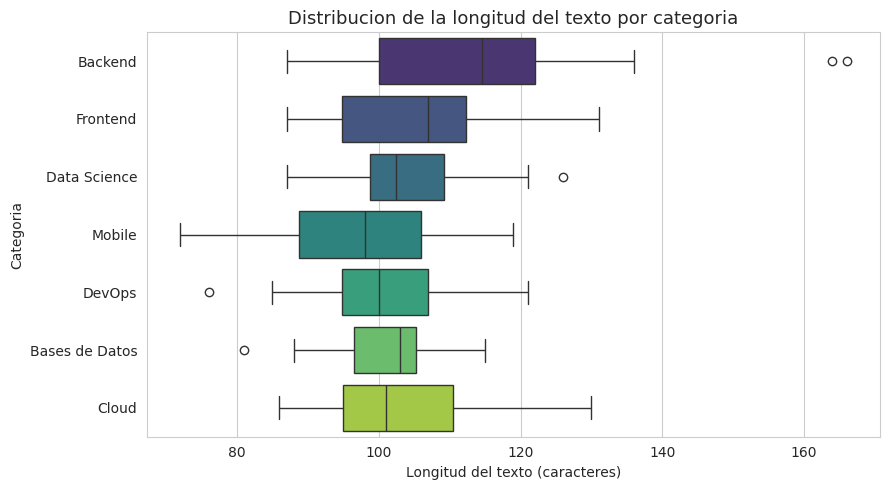

In [6]:
# Analizamos la longitud del texto por categoria. Textos demasiado cortos
# aportan poca senal al modelo; textos muy largos podrian sesgar el TF-IDF.
df['longitud_texto'] = df['texto'].str.len()

plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x='longitud_texto', y='categoria', palette='viridis')
plt.title('Distribucion de la longitud del texto por categoria', fontsize=13)
plt.xlabel('Longitud del texto (caracteres)')
plt.ylabel('Categoria')
plt.tight_layout()
plt.show()

## 3. Preprocesamiento de texto

El preprocesamiento limpia el texto para que el modelo se enfoque en las
palabras que realmente aportan significado:

- Convertimos todo a minusculas (para que 'Java' y 'java' se traten igual)
- Eliminamos caracteres que no sean letras, numeros o espacios
- Eliminamos "stopwords" (palabras muy frecuentes sin valor discriminativo,
  como 'el', 'la', 'de', 'para')
- Descartamos palabras muy cortas (menos de 3 letras), que suelen ser ruido


In [7]:
# Lista de stopwords en espanol. Incluimos tanto stopwords generales
# del idioma como palabras genericas que aparecen en casi todos los
# textos del dataset (ej. 'contenido', 'tutorial') y que por lo tanto
# no ayudan a distinguir una categoria de otra.
STOPWORDS_ES = set((
    'el la los las un una unos unas de del al a en y o u que que '
    'para por con sin sobre entre como se su sus es son fue ser '
    'este esta estos estas ese esa esos esas lo le les nos '
    'mas muy pero si no ya tambien asi como utilizando mediante '
    'utiliza utilizar presenta presentan explica explican cubre '
    'cubren muestra muestran contenido tutorial articulo'
).split())


def limpiar_texto(texto):
    """
    Limpia un texto crudo para dejarlo listo para vectorizar.

    Pasos:
    1. Pasa todo a minusculas.
    2. Elimina cualquier caracter que no sea letra (incluye acentos y enie),
       numero o espacio -- fuera puntuacion, simbolos, etc.
    3. Separa en palabras (tokeniza) por espacios.
    4. Descarta stopwords y palabras de 2 letras o menos.
    5. Vuelve a unir las palabras filtradas en un solo string.
    """
    texto = texto.lower()
    texto = re.sub(r'[^a-zA-Z0-9\u00e1\u00e9\u00ed\u00f3\u00fa\u00f1\u00fc\s]', ' ', texto)
    palabras = texto.split()
    palabras = [p for p in palabras if p not in STOPWORDS_ES and len(p) > 2]
    return ' '.join(palabras)

In [8]:
# Combinamos titulo + texto en un solo campo: el titulo suele contener
# palabras muy representativas de la categoria (ej. 'Introduccion a Docker'),
# asi que darle mas peso ayuda a la clasificacion.
df['texto_completo'] = df['titulo'] + ' ' + df['texto']
df['texto_limpio'] = df['texto_completo'].apply(limpiar_texto)

# Comparamos un ejemplo antes/despues para verificar que la limpieza funciona bien.
print('ANTES:')
print(df.loc[0, 'texto_completo'])
print()
print('DESPUES:')
print(df.loc[0, 'texto_limpio'])

ANTES:
Introducción a Spring Boot En este contenido se presentan los conceptos básicos para la creación de APIs REST utilizando Java y Spring Boot, incluyendo el manejo de controladores y servicios.

DESPUES:
introducción spring boot conceptos básicos creación apis rest java spring boot incluyendo manejo controladores servicios


## 4. Division en conjunto de entrenamiento y prueba

Separamos los datos en dos grupos:
- **Entrenamiento (80%)**: lo que el modelo usa para aprender.
- **Prueba (20%)**: datos que el modelo nunca ve durante el entrenamiento,
  usados solo para medir que tan bien generaliza.

Usamos `stratify=y` para que la proporcion de cada categoria se mantenga
igual en ambos conjuntos -- crucial cuando ya de por si hay pocos ejemplos
por clase, para no dejar una categoria sub-representada en el test.


In [9]:
X = df['texto_limpio']
y = df['categoria']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

print(f'Ejemplos de entrenamiento: {len(X_train)}')
print(f'Ejemplos de prueba: {len(X_test)}')
print(f'Ejemplos de prueba por categoria (aprox): {len(X_test) // y.nunique()}')

Ejemplos de entrenamiento: 224
Ejemplos de prueba: 56
Ejemplos de prueba por categoria (aprox): 8


## 5. Vectorizacion TF-IDF

TF-IDF (Term Frequency - Inverse Document Frequency) convierte cada texto en
un vector numerico donde cada dimension representa una palabra (o bigrama).
El peso de cada palabra es alto si aparece mucho en ese documento pero poco
en el resto del corpus -- es decir, prioriza palabras *distintivas* sobre
palabras genericas.

Importante: el vectorizador se **ajusta (fit) solo con datos de entrenamiento**.
Si lo ajustaramos tambien con datos de prueba, el modelo "veria" informacion
que no deberia conocer todavia (fuga de datos / data leakage).


In [10]:
vectorizer = TfidfVectorizer(
    max_features=3000,      # limitamos el vocabulario a los 3000 terminos mas relevantes
    ngram_range=(1, 2),     # incluye palabras individuales y pares de palabras (ej. 'spring boot')
    min_df=1,               # una palabra debe aparecer al menos 1 vez para incluirse
)

X_train_tfidf = vectorizer.fit_transform(X_train)  # aprende el vocabulario Y transforma
X_test_tfidf = vectorizer.transform(X_test)        # solo transforma, con el vocabulario ya aprendido

print(f'Forma de la matriz de entrenamiento: {X_train_tfidf.shape}')
print(f'(filas = documentos, columnas = terminos del vocabulario)')

Forma de la matriz de entrenamiento: (224, 2761)
(filas = documentos, columnas = terminos del vocabulario)


## 6. Entrenamiento con busqueda de hiperparametros

En vez de entrenar un solo modelo con parametros arbitrarios, usamos
**GridSearchCV**: prueba automaticamente varias combinaciones de
hiperparametros y, para cada una, evalua el desempeno con **validacion
cruzada de 5 folds** (divide el set de entrenamiento en 5 partes, entrena
con 4 y valida con 1, rotando 5 veces). Esto da una medicion mucho mas
confiable que un solo split, especialmente con un dataset de este tamano,
y nos deja quedarnos con la combinacion que realmente generaliza mejor
-- no la que por azar acerto mas en un unico split.


In [11]:
# Grilla de hiperparametros a probar para la Regresion Logistica:
# - C: controla la regularizacion (valores mas bajos = mas regularizacion,
#   util para evitar sobreajuste con pocos datos)
# - class_weight: 'balanced' ajusta automaticamente el peso de cada clase
#   segun su frecuencia, util si el dataset no esta perfectamente balanceado
# - solver: algoritmo de optimizacion interno
# Nota: 'liblinear' no soporta clasificacion multiclase con mas de 2 clases
# en este contexto, por eso usamos solvers que si lo soportan nativamente.
param_grid = {
    'C': [0.1, 0.5, 1, 5, 10],
    'class_weight': [None, 'balanced'],
    'solver': ['lbfgs', 'saga'],
}

cv_estratificado = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=LogisticRegression(max_iter=2000),
    param_grid=param_grid,
    scoring='f1_macro',   # f1 macro pondera todas las categorias por igual, no solo la mayoritaria
    cv=cv_estratificado,
    n_jobs=-1,
)

grid_search.fit(X_train_tfidf, y_train)

print('Mejores hiperparametros encontrados:')
print(grid_search.best_params_)
print(f'Mejor F1-macro promedio en validacion cruzada: {grid_search.best_score_:.3f}')

Mejores hiperparametros encontrados:
{'C': 5, 'class_weight': 'balanced', 'solver': 'saga'}
Mejor F1-macro promedio en validacion cruzada: 0.859


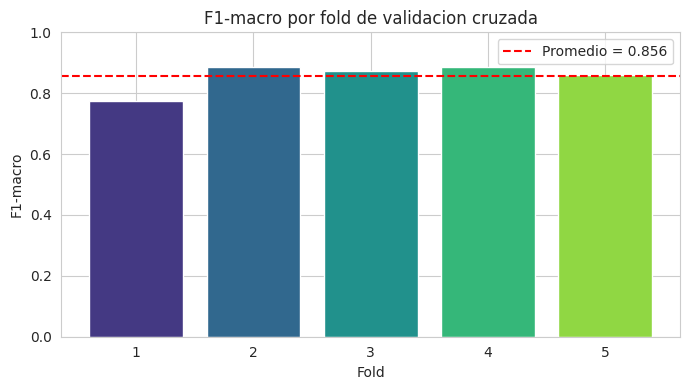

In [12]:
# Nos quedamos con el mejor modelo encontrado por la busqueda.
clf = grid_search.best_estimator_

# Visualizamos como se desempenaron los distintos folds de validacion cruzada
# con la mejor combinacion de hiperparametros, para confirmar que el resultado
# es estable y no producto de la suerte en un solo split.
scores_cv = cross_val_score(clf, X_train_tfidf, y_train, cv=cv_estratificado, scoring='f1_macro')

plt.figure(figsize=(7, 4))
plt.bar(range(1, len(scores_cv) + 1), scores_cv, color=sns.color_palette('viridis', len(scores_cv)))
plt.axhline(scores_cv.mean(), color='red', linestyle='--', label=f'Promedio = {scores_cv.mean():.3f}')
plt.title('F1-macro por fold de validacion cruzada')
plt.xlabel('Fold')
plt.ylabel('F1-macro')
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

## 7. Evaluacion final sobre el conjunto de prueba

Esta es la medicion mas honesta: el modelo nunca vio estos datos, ni
siquiera durante la busqueda de hiperparametros.


In [13]:
y_pred = clf.predict(X_test_tfidf)

print(f'Accuracy: {accuracy_score(y_test, y_pred):.3f}')
print(f'F1-score (macro): {f1_score(y_test, y_pred, average="macro"):.3f}')
print()
print(classification_report(y_test, y_pred))

Accuracy: 0.893
F1-score (macro): 0.891

                precision    recall  f1-score   support

       Backend       0.80      1.00      0.89         8
Bases de Datos       1.00      1.00      1.00         8
         Cloud       0.86      0.75      0.80         8
  Data Science       1.00      0.88      0.93         8
        DevOps       0.86      0.75      0.80         8
      Frontend       0.88      0.88      0.88         8
        Mobile       0.89      1.00      0.94         8

      accuracy                           0.89        56
     macro avg       0.90      0.89      0.89        56
  weighted avg       0.90      0.89      0.89        56



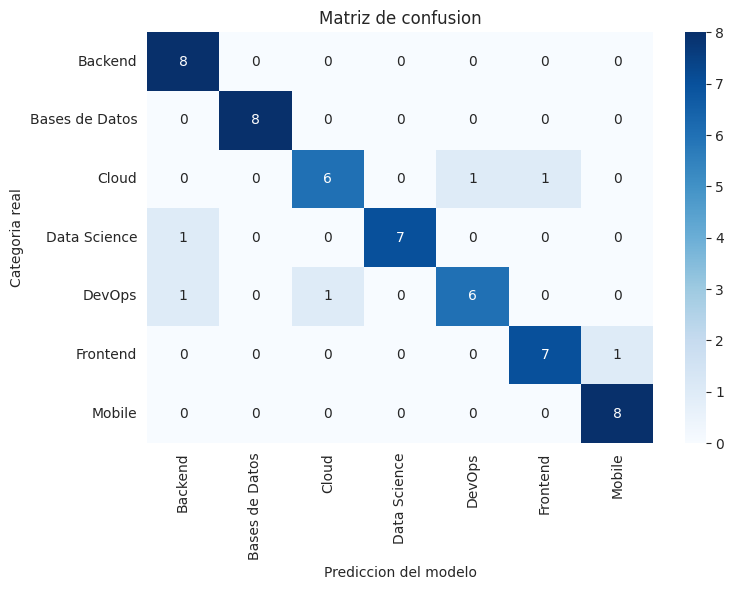

In [14]:
# La matriz de confusion muestra, para cada categoria real (filas),
# que categoria predijo el modelo (columnas). La diagonal principal
# son los aciertos; todo lo que esta fuera de la diagonal son errores
# -- y nos dice exactamente que categorias se confunden entre si.
cm = confusion_matrix(y_test, y_pred, labels=clf.classes_)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=clf.classes_, yticklabels=clf.classes_)
plt.xlabel('Prediccion del modelo')
plt.ylabel('Categoria real')
plt.title('Matriz de confusion')
plt.tight_layout()
plt.show()

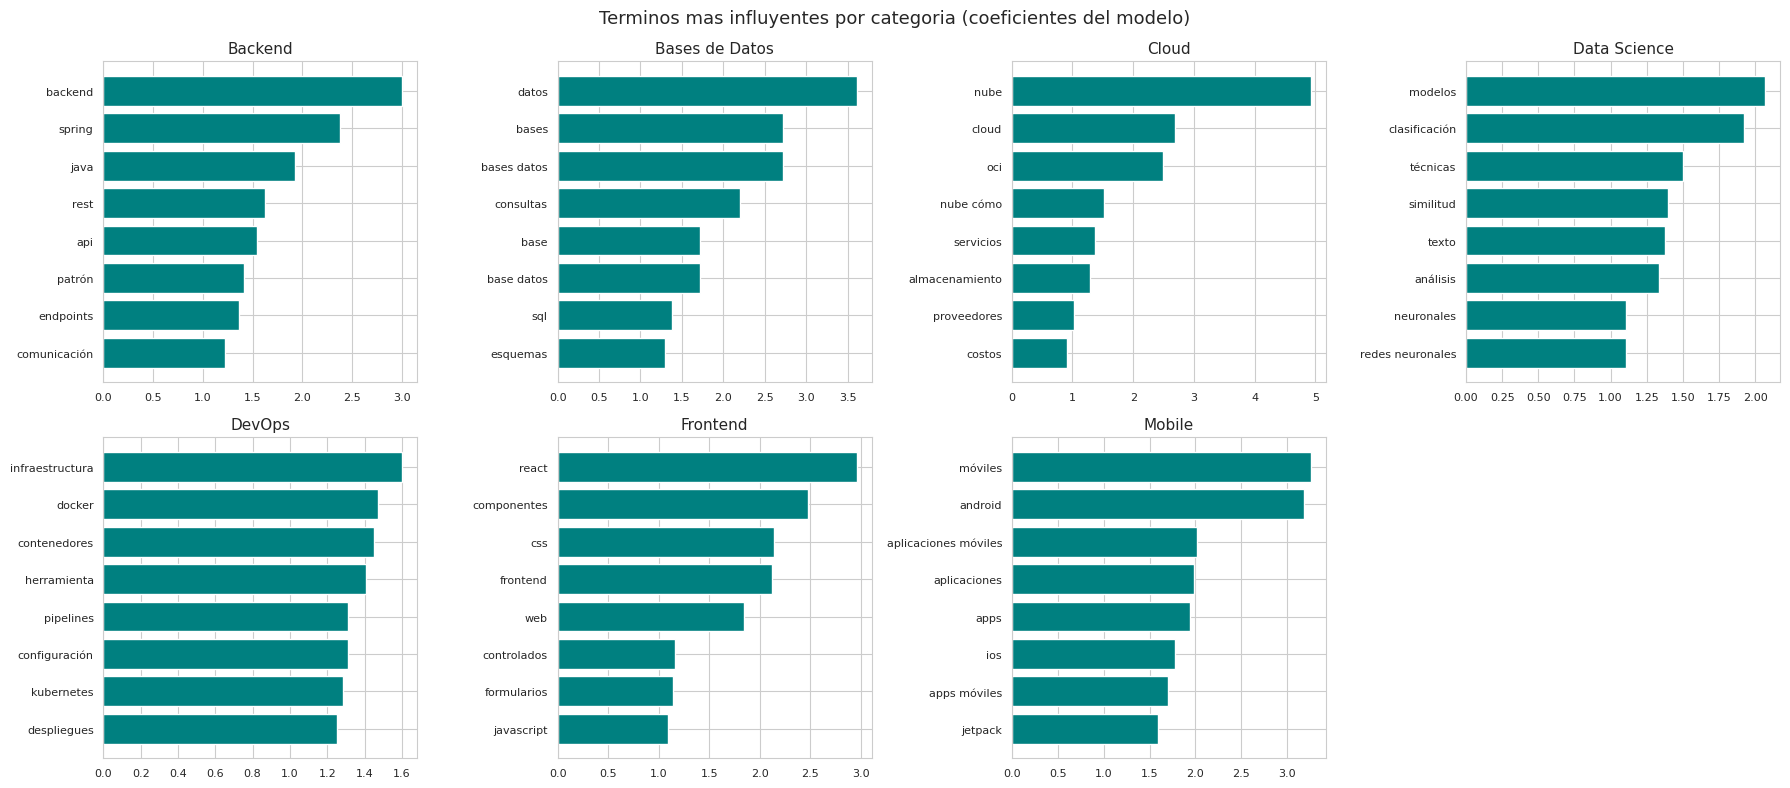

In [15]:
# Palabras mas influyentes por categoria: usamos los coeficientes
# aprendidos por la Regresion Logistica para ver que terminos empujan
# la prediccion hacia cada clase. Esto le da explicabilidad al modelo
# (no es una caja negra).
feature_names = np.array(vectorizer.get_feature_names_out())

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for idx, categoria in enumerate(clf.classes_):
    coeficientes = clf.coef_[idx]
    top_indices = np.argsort(coeficientes)[-8:]  # 8 palabras con mayor peso positivo
    top_palabras = feature_names[top_indices]
    top_valores = coeficientes[top_indices]

    axes[idx].barh(top_palabras, top_valores, color='teal')
    axes[idx].set_title(categoria, fontsize=11)
    axes[idx].tick_params(labelsize=8)

# Ocultamos el subplot sobrante (7 categorias en grilla de 8)
for j in range(len(clf.classes_), len(axes)):
    axes[j].axis('off')

plt.suptitle('Terminos mas influyentes por categoria (coeficientes del modelo)', fontsize=13)
plt.tight_layout()
plt.show()

## 8. Extraccion de palabras clave

No entrenamos un modelo aparte para esto: reutilizamos la misma matriz
TF-IDF. Para un documento dado, las palabras con mayor peso TF-IDF son,
por definicion, las mas distintivas de ese texto en particular -- es
decir, buenas candidatas a "palabras clave".


In [16]:
def extraer_palabras_clave(texto_crudo, vectorizer, top_n=5):
    """
    Extrae las top_n palabras/bigramas con mayor peso TF-IDF de un texto.

    Parametros:
        texto_crudo (str): texto sin procesar (titulo + cuerpo, por ejemplo)
        vectorizer (TfidfVectorizer): vectorizador ya entrenado (fit) sobre el corpus
        top_n (int): cuantas palabras clave devolver

    Retorna:
        list[str]: lista de palabras clave ordenadas de mayor a menor relevancia
    """
    texto_limpio = limpiar_texto(texto_crudo)
    vector = vectorizer.transform([texto_limpio])
    nombres_terminos = vectorizer.get_feature_names_out()

    pesos = vector.toarray()[0]
    indices_ordenados = pesos.argsort()[::-1][:top_n]
    indices_validos = [i for i in indices_ordenados if pesos[i] > 0]  # descarta pesos en cero

    return [nombres_terminos[i] for i in indices_validos]

Texto de ejemplo:
Introducción a Spring Boot En este contenido se presentan los conceptos básicos para la creación de APIs REST utilizando Java y Spring Boot, incluyendo el manejo de controladores y servicios.



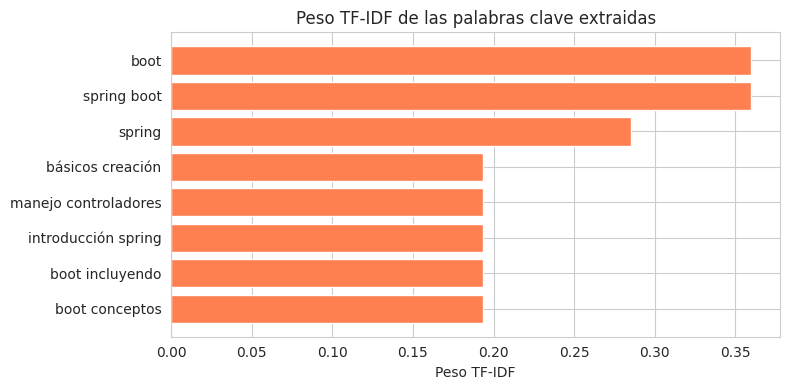

In [17]:
# Visualizamos el proceso de extraccion de palabras clave sobre un ejemplo
# real, mostrando el peso TF-IDF de cada palabra clave elegida.
ejemplo_texto = df.iloc[0]['texto_completo']
texto_limpio_ejemplo = limpiar_texto(ejemplo_texto)
vector_ejemplo = vectorizer.transform([texto_limpio_ejemplo])
nombres_terminos = vectorizer.get_feature_names_out()
pesos_ejemplo = vector_ejemplo.toarray()[0]

top_n = 8
indices_top = pesos_ejemplo.argsort()[::-1][:top_n]
indices_top = [i for i in indices_top if pesos_ejemplo[i] > 0]

palabras_top = [nombres_terminos[i] for i in indices_top]
valores_top = [pesos_ejemplo[i] for i in indices_top]

print('Texto de ejemplo:')
print(ejemplo_texto)
print()

plt.figure(figsize=(8, 4))
plt.barh(palabras_top[::-1], valores_top[::-1], color='coral')
plt.title('Peso TF-IDF de las palabras clave extraidas', fontsize=12)
plt.xlabel('Peso TF-IDF')
plt.tight_layout()
plt.show()

## 9. Funcion de prediccion completa

Esta es la funcion que replicara el endpoint de la API: recibe titulo y
texto, y devuelve exactamente el mismo formato de salida definido en el
enunciado del hackathon (`categoria`, `probabilidad`, `informacion_adicional`).


In [18]:
def predecir_contenido(titulo, texto, top_n_keywords=5):
    """
    Procesa un contenido tecnico y devuelve su clasificacion + palabras clave,
    replicando el contrato esperado por la API REST del proyecto.

    Parametros:
        titulo (str): titulo del contenido
        texto (str): cuerpo del contenido
        top_n_keywords (int): cantidad de palabras clave a devolver

    Retorna:
        dict: {'categoria': str, 'probabilidad': float, 'informacion_adicional': list[str]}
    """
    texto_completo = f'{titulo} {texto}'
    texto_limpio = limpiar_texto(texto_completo)

    vector_tfidf = vectorizer.transform([texto_limpio])

    categoria = clf.predict(vector_tfidf)[0]
    probabilidades = clf.predict_proba(vector_tfidf)[0]
    probabilidad = round(float(max(probabilidades)), 2)

    palabras_clave = extraer_palabras_clave(texto_completo, vectorizer, top_n=top_n_keywords)

    return {
        'categoria': categoria,
        'probabilidad': probabilidad,
        'informacion_adicional': palabras_clave,
    }

In [19]:
# Probamos con tres ejemplos nuevos, cumpliendo el requisito minimo del
# hackathon de 'minimo tres ejemplos de uso'.
ejemplos_prueba = [
    ('Introduccion a Spring Boot',
     'En este contenido se presentan los conceptos basicos para la creacion de APIs REST utilizando Java y Spring Boot.'),
    ('Clustering con K-Means',
     'Se presenta el algoritmo K-Means para agrupar datos no etiquetados en clusteres basados en similitud.'),
    ('Introduccion a Docker',
     'Este contenido presenta los conceptos basicos de Docker, incluyendo imagenes, contenedores y Dockerfiles.'),
]

for titulo, texto in ejemplos_prueba:
    resultado = predecir_contenido(titulo, texto)
    print(f'Titulo: {titulo}')
    print(f'Resultado: {resultado}')
    print()

Titulo: Introduccion a Spring Boot
Resultado: {'categoria': 'Backend', 'probabilidad': 0.83, 'informacion_adicional': ['boot', 'spring boot', 'spring', 'boot conceptos', 'rest java']}

Titulo: Clustering con K-Means
Resultado: {'categoria': 'Data Science', 'probabilidad': 0.66, 'informacion_adicional': ['means', 'basados similitud', 'agrupar', 'agrupar datos', 'algoritmo means']}

Titulo: Introduccion a Docker
Resultado: {'categoria': 'DevOps', 'probabilidad': 0.62, 'informacion_adicional': ['docker', 'dockerfiles', 'docker incluyendo', 'docker conceptos', 'contenedores dockerfiles']}



## 10. Serializacion del modelo (joblib)

Guardamos el modelo entrenado y el vectorizador para poder cargarlos
despues en el servicio de la API, sin tener que reentrenar cada vez.


In [20]:
with open('modelo_clasificador.pkl', 'wb') as f:
    pickle.dump(clf, f)

with open('vectorizer_tfidf.pkl', 'wb') as f:
    pickle.dump(vectorizer, f)

print('Modelo y vectorizador guardados correctamente:')
print(' - modelo_clasificador.pkl')
print(' - vectorizer_tfidf.pkl')

Modelo y vectorizador guardados correctamente:
 - modelo_clasificador.pkl
 - vectorizer_tfidf.pkl


## Como cargar el modelo despues (para la API)

```python
import pickle

with open('modelo_clasificador.pkl', 'rb') as f:
    clf = pickle.load(f)

with open('vectorizer_tfidf.pkl', 'rb') as f:
    vectorizer = pickle.load(f)

# Luego se necesitan las mismas funciones limpiar_texto(), extraer_palabras_clave()
# y predecir_contenido() definidas en este notebook para poder usarlos.
```

Estos archivos `.pkl` son los que el servicio Python (Flask/FastAPI) cargaria
para exponer el endpoint `POST /predict`, que la API en Java del equipo de
Backend podria consumir.
